# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [2]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [3]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) 
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

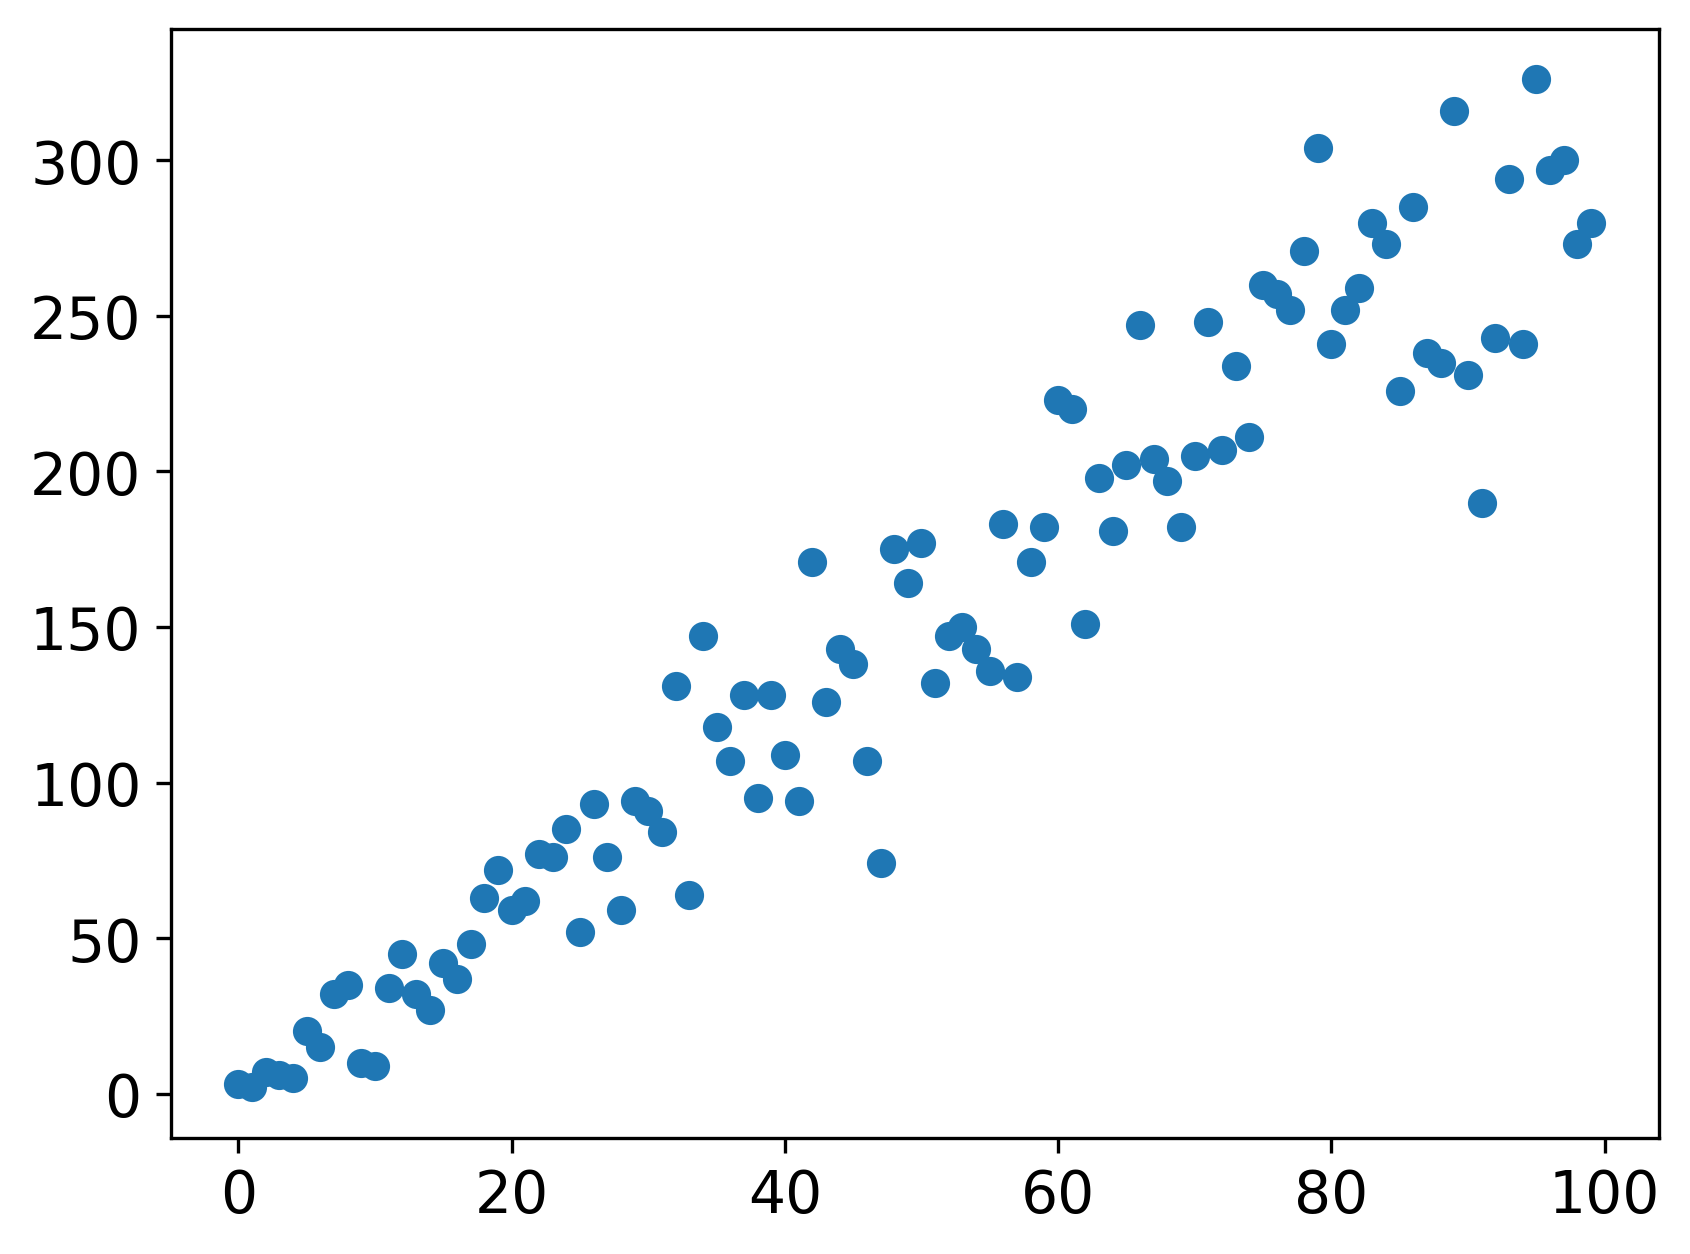

In [4]:
plt.scatter(x, yp);

### Pregunta 

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?
- **Sí, efectivamente los datos siguen una tendencia lineal: del 0 al 100 podríamos dibujar una linea recta que siga los puntos.**
- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?
- **Hay dispersión alrededor de toda la recta, aunque no se dispersan de la misma forma.**
- ¿Qué podría implicar esto al mirar residuos más adelante?
- **Podría implicar que la diferencia entre los datos observados y predichos vaya cambiando.**

In [5]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [6]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [7]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


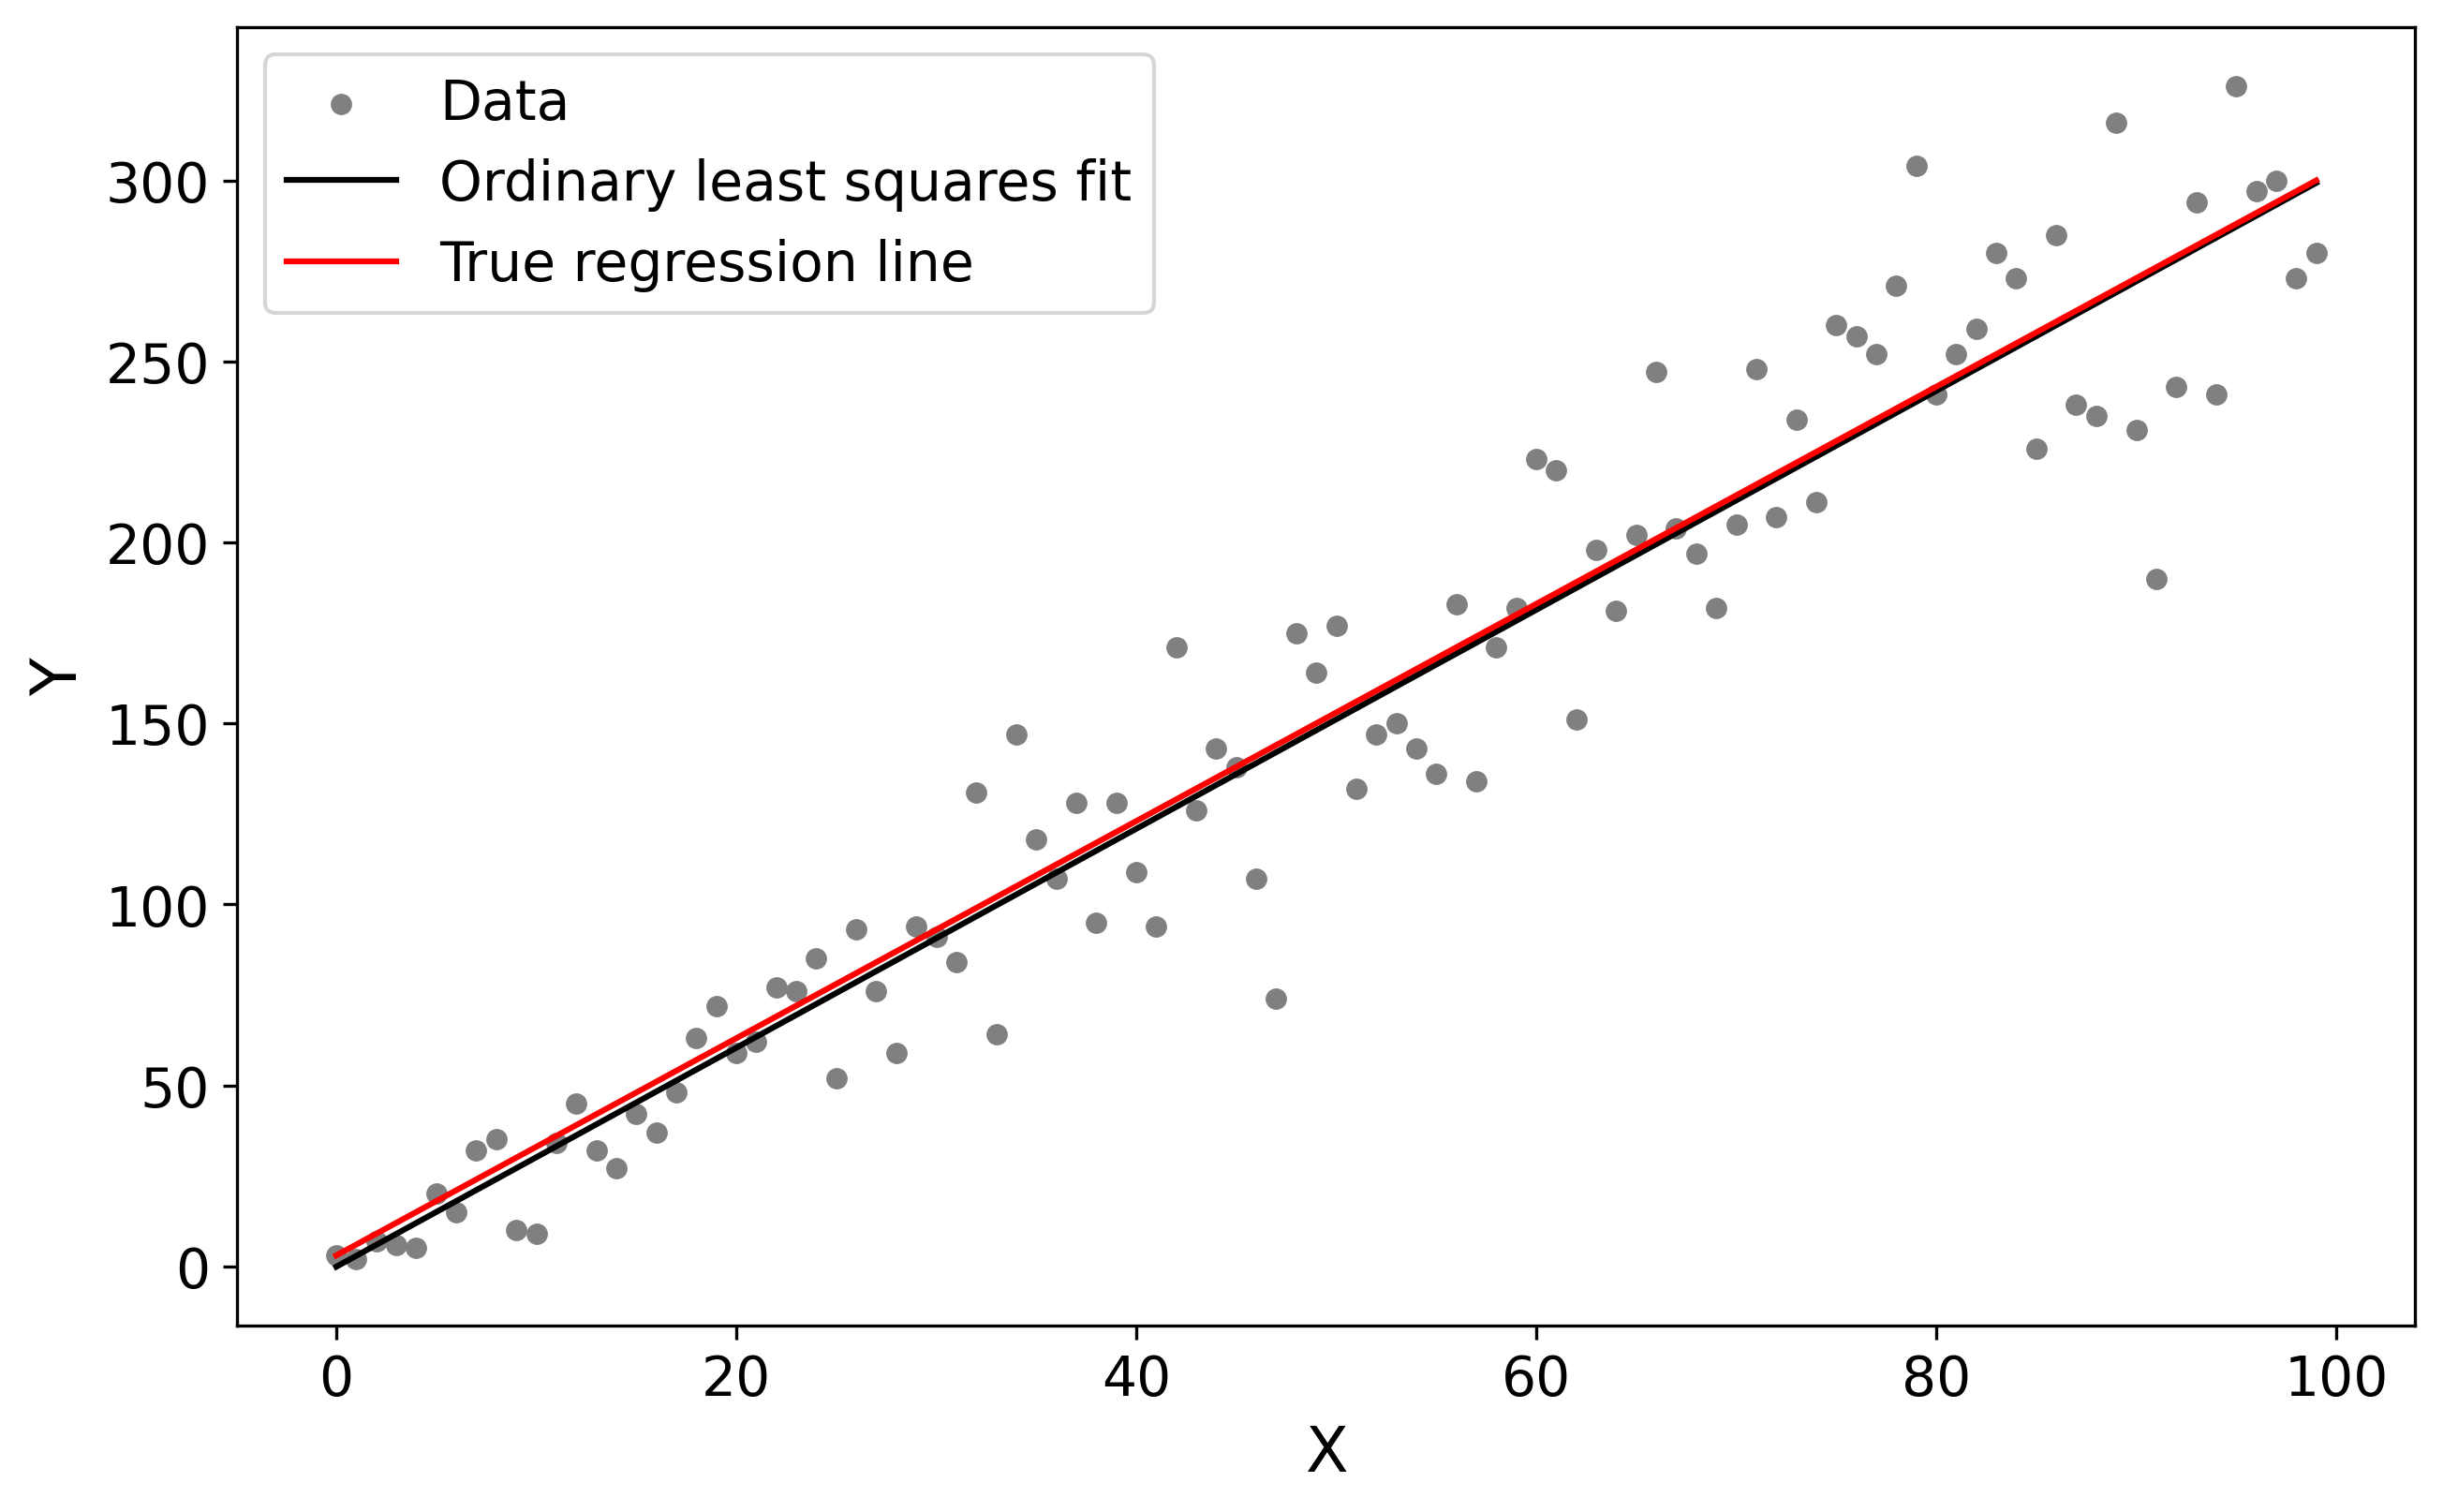

In [8]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?
- **No son exactamente iguales, pero son similares. Porque luego de crear el modelo, el intercepto y la pendiente usan distintos valores.**
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?
- **Representa la dirección a la que se inclinan los datos.**

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [9]:
(x - x.mean())**2

array([2.45025e+03, 2.35225e+03, 2.25625e+03, 2.16225e+03, 2.07025e+03,
       1.98025e+03, 1.89225e+03, 1.80625e+03, 1.72225e+03, 1.64025e+03,
       1.56025e+03, 1.48225e+03, 1.40625e+03, 1.33225e+03, 1.26025e+03,
       1.19025e+03, 1.12225e+03, 1.05625e+03, 9.92250e+02, 9.30250e+02,
       8.70250e+02, 8.12250e+02, 7.56250e+02, 7.02250e+02, 6.50250e+02,
       6.00250e+02, 5.52250e+02, 5.06250e+02, 4.62250e+02, 4.20250e+02,
       3.80250e+02, 3.42250e+02, 3.06250e+02, 2.72250e+02, 2.40250e+02,
       2.10250e+02, 1.82250e+02, 1.56250e+02, 1.32250e+02, 1.10250e+02,
       9.02500e+01, 7.22500e+01, 5.62500e+01, 4.22500e+01, 3.02500e+01,
       2.02500e+01, 1.22500e+01, 6.25000e+00, 2.25000e+00, 2.50000e-01,
       2.50000e-01, 2.25000e+00, 6.25000e+00, 1.22500e+01, 2.02500e+01,
       3.02500e+01, 4.22500e+01, 5.62500e+01, 7.22500e+01, 9.02500e+01,
       1.10250e+02, 1.32250e+02, 1.56250e+02, 1.82250e+02, 2.10250e+02,
       2.40250e+02, 2.72250e+02, 3.06250e+02, 3.42250e+02, 3.802

In [10]:
nume = np.sum(((x - x.mean())*(yp - yp.mean())))
dem = np.sum((x - x.mean())**2)

In [11]:
beta1 = nume/dem

beta0= yp.mean() - beta1*x.mean()

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [12]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'max_error', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'roc_auc', 'roc_auc_ovo', 'roc_auc_ovo_weight

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [13]:
cv = KFold(n_splits=5) #definimos splits

In [14]:
#scores_r2 = cross_validate(...)
#implemente una validacion cruzada
scores_r2 = cross_validate(model, x.reshape(-1,1), yp, cv = cv, scoring = 'r2', return_train_score=True) #implementación

print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.273 ± 0.319
R2 train: 0.917 ± 0.027


In [15]:
#implemente una validacion cruzada
scores_mse = cross_validate(model, x.reshape(-1,1), yp, cv = cv, scoring = 'neg_mean_squared_error', return_train_score=True) 
#implementación

scores_mae = cross_validate(model, x.reshape(-1,1), yp, cv = cv, scoring = 'neg_mean_absolute_error', return_train_score=True) 
#implementación

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 712.979
MAE test: 19.711


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

In [16]:
ypred = beta0 + beta1*x #y tongo

In [17]:
r = yp - ypred #residuos

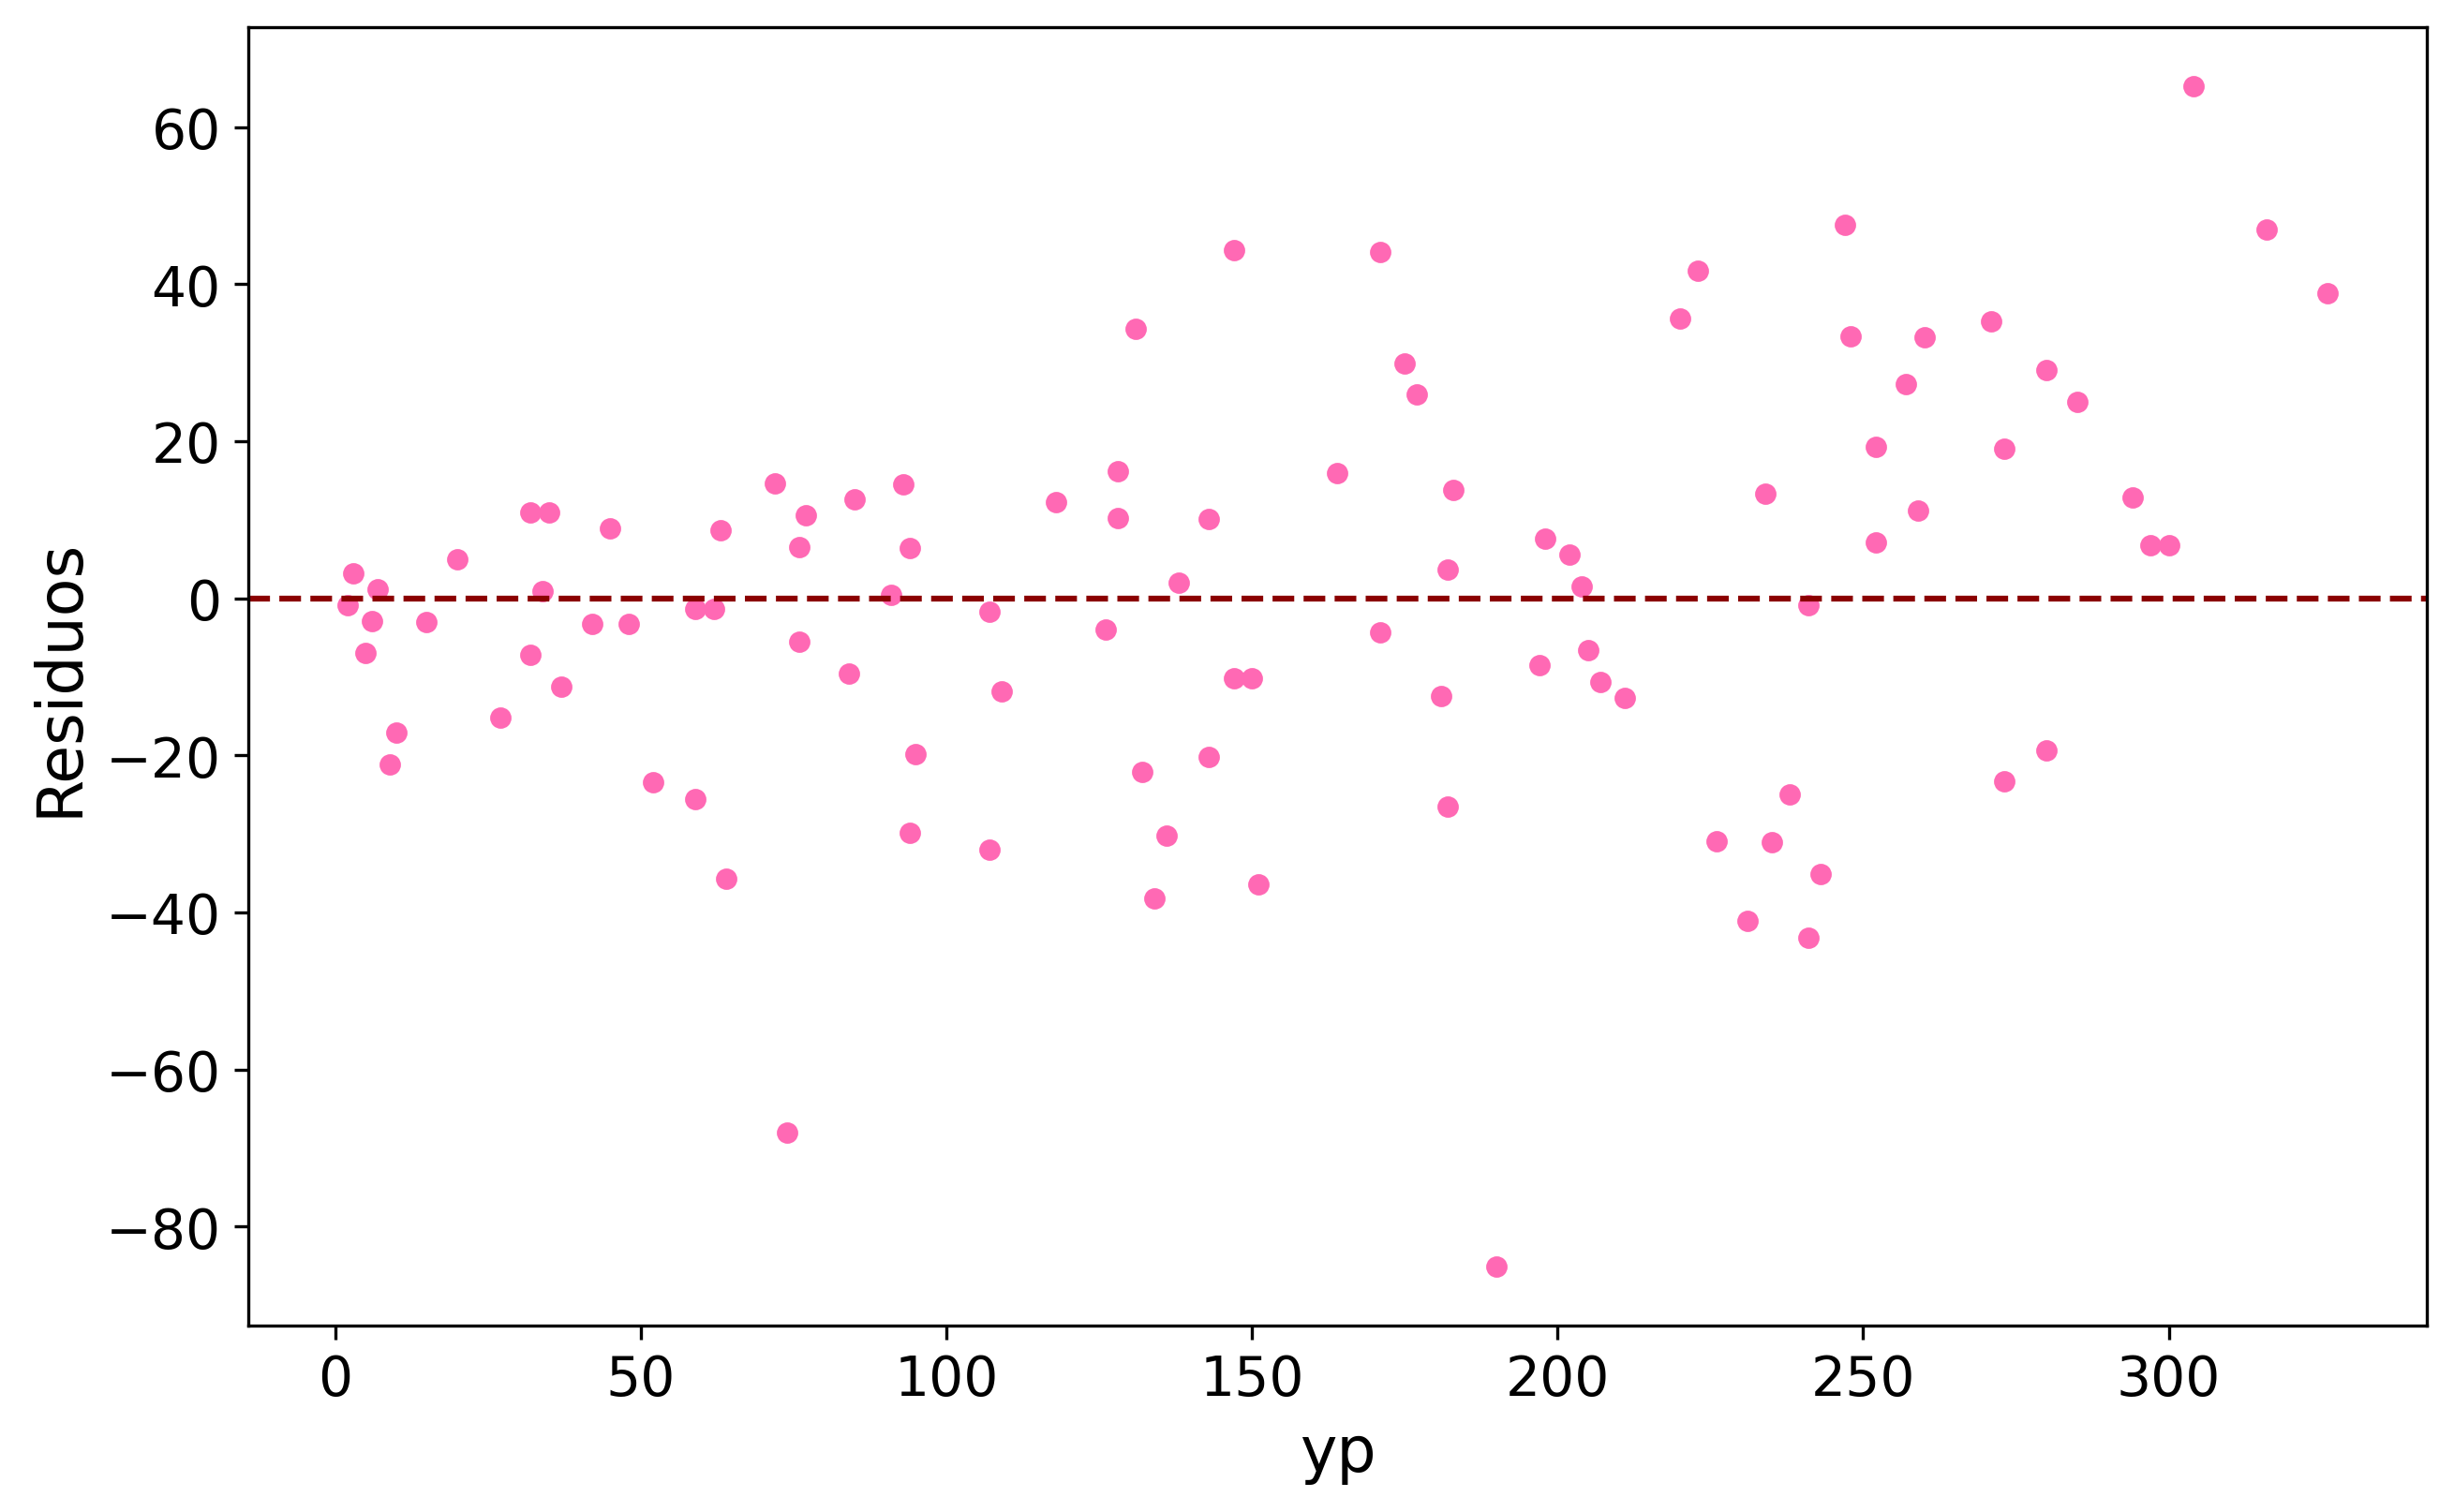

In [18]:
plt.figure(figsize = (10,6))
plt.scatter(yp,r, s = 20, c = 'hotpink')

plt.xlabel('yp')
plt.ylabel('Residuos')
plt.axhline(y=0, color='darkred', linestyle='--')
plt.show()

#### Pregunta 
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?
- **Sí, parecen distribuidos aleatoriamente a medida que se avanza en yp.**
-  ¿La dispersión de los residuos cambia con $x$?
- **Sí, incluso vemos valores bastante alejados del eje.**
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?
- **Que se generó correctamente una distribución Poissoniana para la dispersión.**

### ¿Qué ocurre si agregamos outliers?

In [19]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada 
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

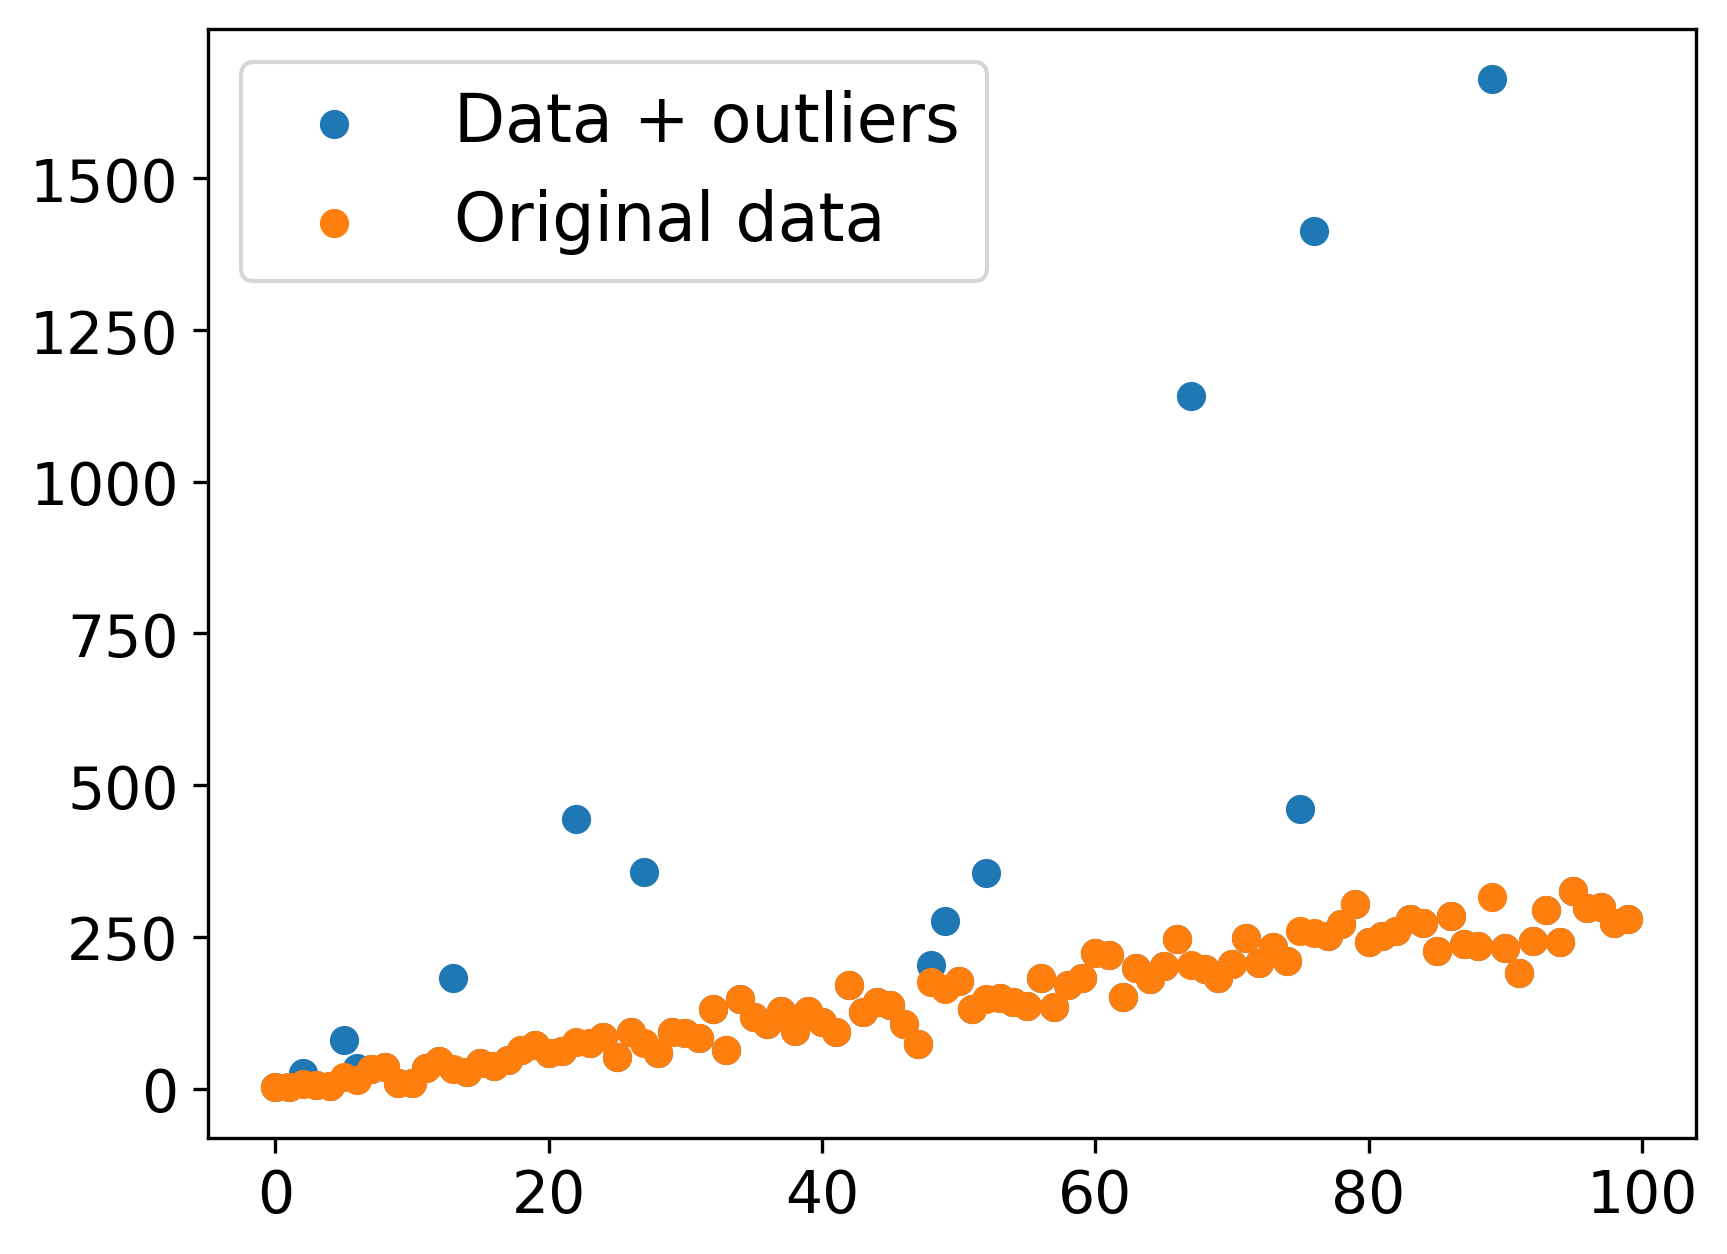

In [20]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda: 
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
- **La recta apenas cambia, se mueve con una pendiente similar.**
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?
- **El intercepto es el que cambia más, aumentando considerablemente en el modelo con outliers.**
- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?
- **Definitivamente la MSE: pasa de los ~700 a los ~45 mil.**
- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?
- **Porque el MSE/RMSE toma el error al cuadrado, amplificando valores muy alejados de la recta.**
- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.
- **En su mayoría están más lejos en y, pero hay 3 puntos que están bastante lejos de ambas rectas.**
- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
- **Está aprendiendo. La mayoría de puntos sigue la tendencia general, con 10 de los 13 cerca de la recta.**
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.
- **Eliminaría solo los 3 outliers que se alejan demasiado de la recta. Si se buscara estudiar el comportamiento general de los datos, los outliers muy alejados no beneficiarían a ese propósito.**

In [21]:
#model_outliers=... #implemente el modelo aca
model_outliers = linear_model.LinearRegression()

In [22]:
model_outliers.fit(x.reshape(-1,1), yp_wo)

LinearRegression()

In [23]:
slope_outliers = model_outliers.coef_[0]
intercept_outliers = model_outliers.intercept_

print(f"Intercepto beta_0 = {intercept_outliers:.3f}")
print(f"Pendiente beta_1 = {slope_outliers:.3f}")

Intercepto beta_0 = 1.548
Pendiente beta_1 = 3.978


#### Comparación métricas con outliers

In [24]:
scores_r2 = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv = cv, scoring = 'r2', return_train_score=True) #implementación

print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : -0.109 ± 0.228
R2 train: 0.233 ± 0.053


In [25]:
scores_mse = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv = cv, scoring = 'neg_mean_squared_error', return_train_score=True) 
#implementación

scores_mae = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv = cv, scoring = 'neg_mean_absolute_error', return_train_score=True) 
#implementación

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 45067.400
MAE test: 95.466


Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [26]:
theta_ne = np.array([[slope_outliers],[intercept_outliers]])
theta_ne

array([[3.97842184],
       [1.54811881]])

Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices 

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [27]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión 

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [28]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [29]:
np.random.seed(10) 

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [30]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [31]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [32]:
loss_bgd

43259.08804185896

In [33]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

30.310266853466768

###  GD estocástico

In [34]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(m) #índice aleatorio
        
        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)
        
        y_one = yp_wo[random_index:random_index+1] 
        
        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [35]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [36]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [37]:
loss_sgd

43385.08132655123

In [38]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

30.10729358736454

### Mini batch GD

In [39]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [40]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [41]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [42]:
loss_mgd

43506.50418469318

In [43]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

29.911683208948485

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

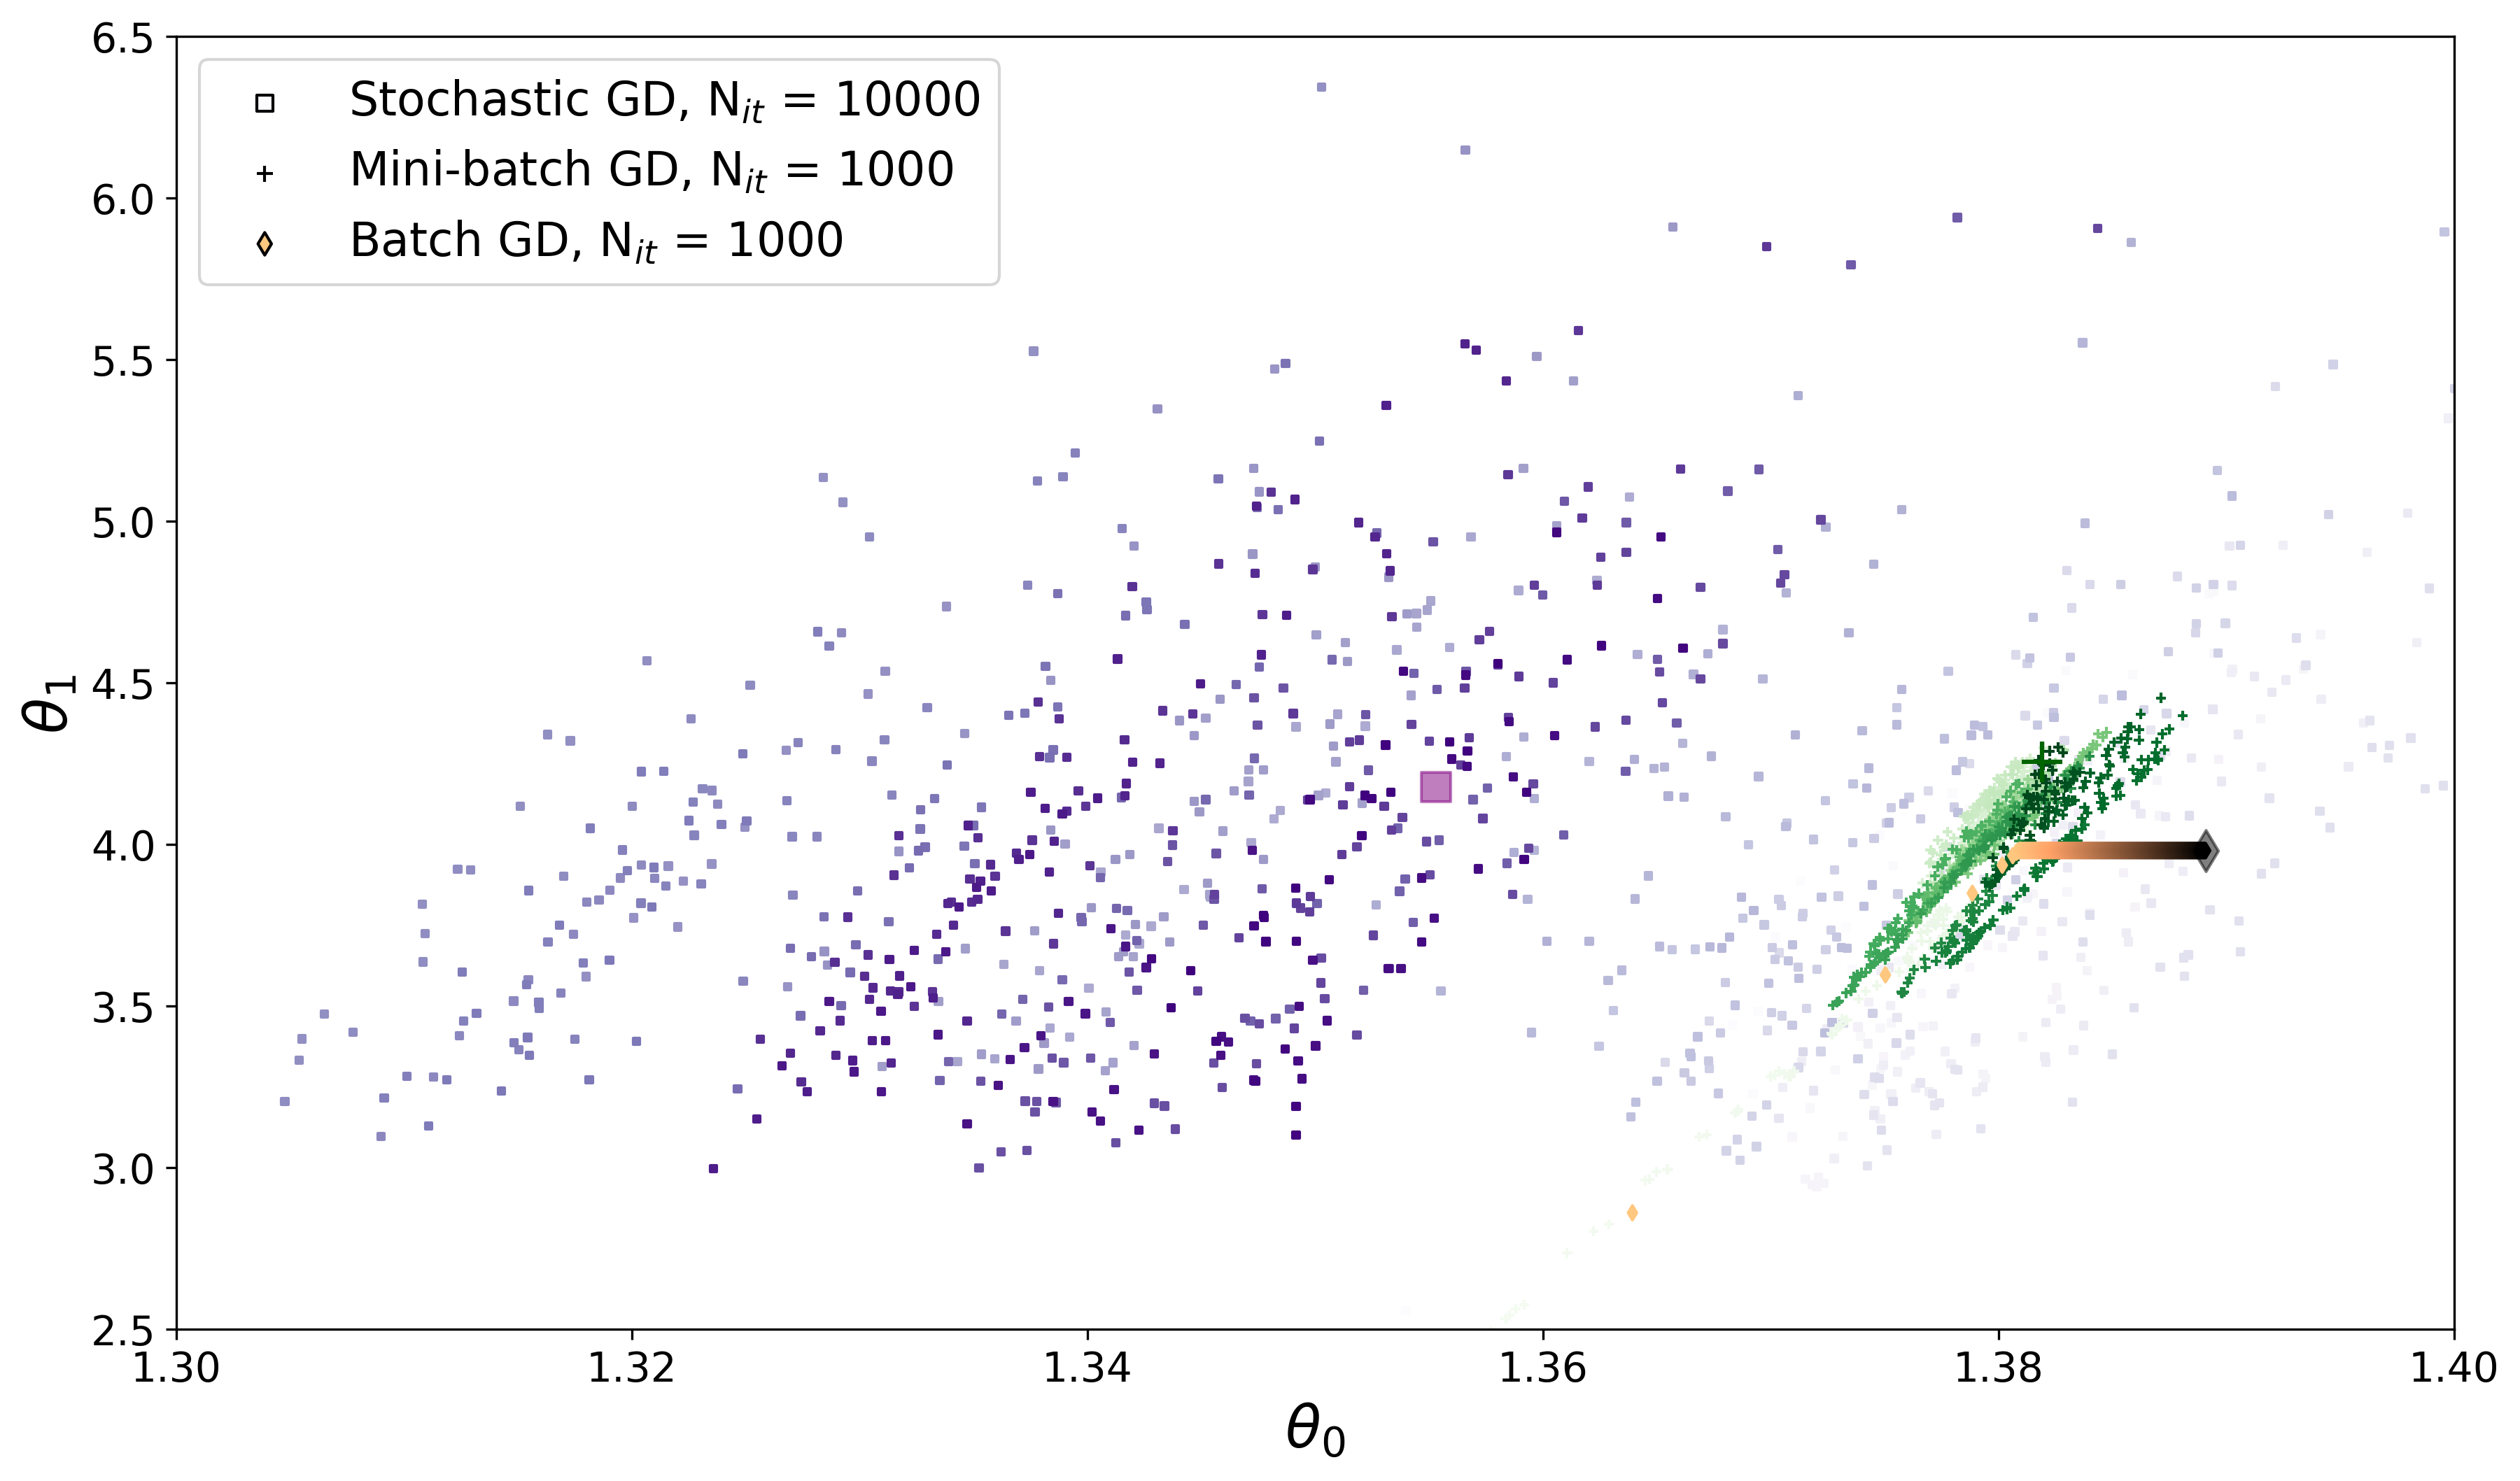

In [44]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()


#### Cambiando learning rate

In [48]:
eta1,eta2,eta3 = 0.000000000005, 0.000005, 0.05

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta3 * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[nan]
 [nan]]


/tmp/ipykernel_3993/1670146292.py:23: RuntimeWarning: invalid value encountered in subtract
  theta = theta - eta3 * gradients


In [ ]:
[[1.37258164]
 [3.87574381]]

[[1.37063528]
 [3.82440493]]


### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones
   
   **y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]**
   
   - cálculo del error o residuo
   
   ***loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)****
   
   - cálculo del gradiente
   
   **gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)**
   
   - actualización de los parámetros
   
   **theta = theta - eta3 * gradients**

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

- **Representan el vector de los coeficientes en la posición 0 o 1 del array.**

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?

- **Pareciera que el theta_0 y theta_1 estuvieran invertidos. No deberían coincidir exactamente por las diferencias al agregar términos de bias.**

4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?

- **Con el pequeño y razonable no cambia demasiado: los valores son similares. Pero con el demasiado grande, los theta terminan tirando valores NaN.**

5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

- **Estamos restando el cambio de theta al theta original, para actualizar cómo se va moviendo.**

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

- **Trabajamos calculando los pasos en la dirección opuesta al gradiente (por eso el descent), hasta llegar al mínimo global.**

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   
   - **Batch Gradient Descent, usa todos los datos en cada paso.**
   
   - ¿Cuál actualiza los parámetros con más ruido?
   
   - **Stochastic Gradient Descent: la aletoriedad genera caminos más caóticos.**
   
   - ¿Cuál parece converger de forma más suave?
   
   - **Batch Gradient Descent, al usar todos los datos en cada paso evita fluctuaciones por el factor azar.**